<a href="https://colab.research.google.com/github/diayuunr/CVL_Assignment01/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CVL_Assignment01**
*   Diayu Nur Aini (24/537751/PA/22792)


**1. TOO DARK IMAGE --> Log Transform (s = T(r) = c log(1+r))**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


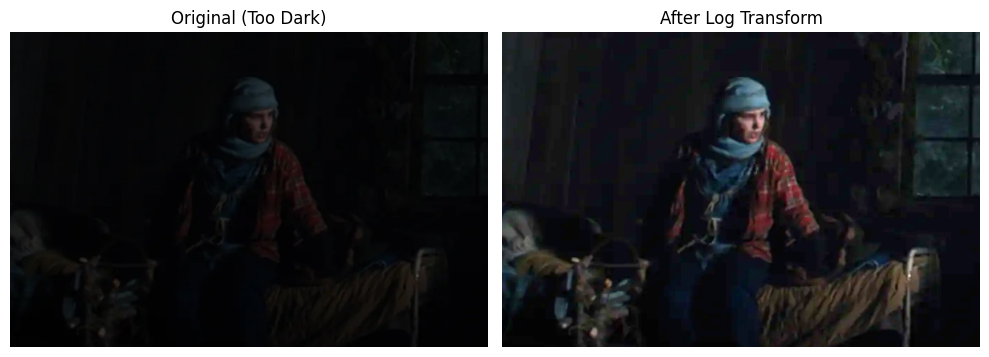

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

#link folder drive gambar: https://drive.google.com/drive/folders/1YSCrkI7UzqDmOdJf-DT7HkURekb3i2Fi?usp=sharing
img = cv2.imread('/content/drive/MyDrive/CVL_Assignment01/dark1.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# normalisasi pixel (0–1) karena 0 ≤ r ≤ 1
img_normal = img / 255

# rumus log transform --> s = T(r) = c log(1+r), dengan 0 ≤ r ≤ 1
c = 1
log_transform1 = c * np.log(1 + img_normal)

# kembalikan ke 0–255
log_transform1 = log_transform1 / np.max(log_transform1)
log_transform1 = np.uint8(log_transform1 * 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title('Original (Too Dark)')
axs[0].axis('off')

axs[1].imshow(log_transform1)
axs[1].set_title('After Log Transform')
axs[1].axis('off')

plt.tight_layout()
plt.show()

**2. TOO DARK IMAGE --> Log Transform (s = c r^γ)**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


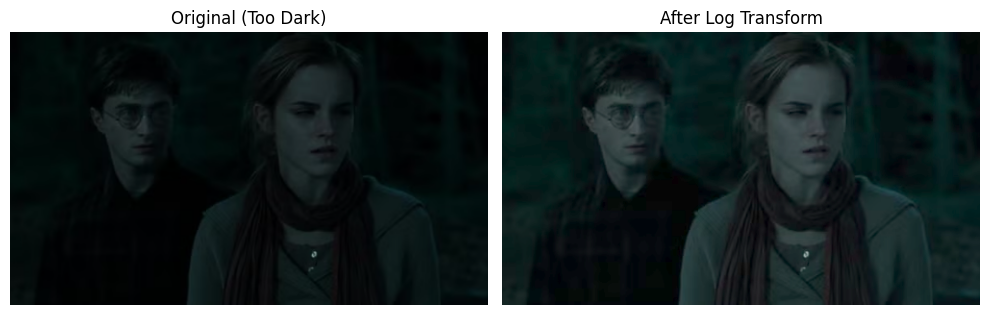

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

#link folder drive gambar: https://drive.google.com/drive/folders/1YSCrkI7UzqDmOdJf-DT7HkURekb3i2Fi?usp=sharing
img = cv2.imread('/content/drive/MyDrive/CVL_Assignment01/dark3.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# normalisasi pixel (0–1) karena 0 ≤ r ≤ 1
img_normal = img / 255

γ = 0.7
c = 1

# rumus log transform --> s = c r^γ, dengan γ ≥ 0 dan 0 ≤ r ≤ 1
log_transform2 = c * (img_normal ** γ)

# kembalikan ke 0-255
log_transform2 = np.uint8(log_transform2 * 255)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title('Original (Too Dark)')
axs[0].axis('off')

axs[1].imshow(log_transform2)
axs[1].set_title('After Log Transform')
axs[1].axis('off')

plt.tight_layout()
plt.show()

**3. LOW CONTRAST IMAGE --> Contrast Stretching**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


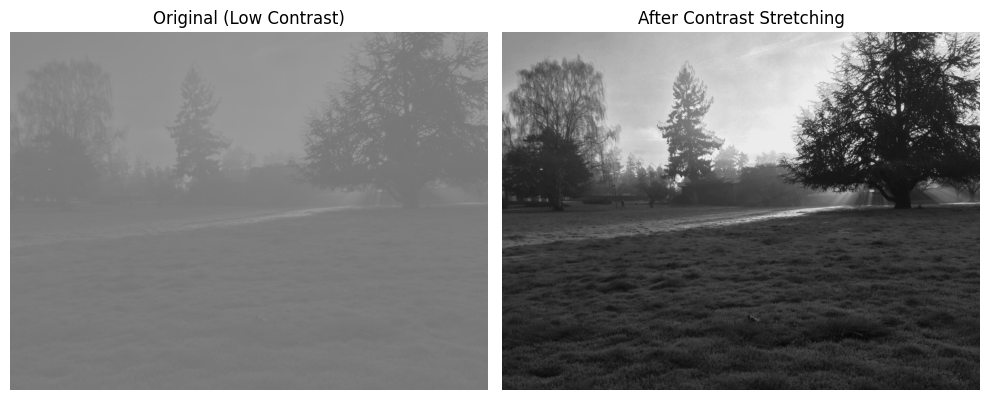

In [26]:
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

#link folder drive gambar: https://drive.google.com/drive/folders/1YSCrkI7UzqDmOdJf-DT7HkURekb3i2Fi?usp=sharing
path_folder = '/content/drive/MyDrive/CVL_Assignment01/'
files = os.listdir(path_folder)

img_path = os.path.join(path_folder,'lowContrast1.png')
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# cari min dan max pixel
min_in = np.min(img)
max_in = np.max(img)

# range output
a = 0
b = 255

# rumus contrast stretching --> P_out = (P_in - min) * ( (b - a) / (max_in - min_in) ) + a
img_stretched = (img - min_in) * ((b - a) / (max_in - min_in)) + a

# ubah ke integer
img_stretched = img_stretched.astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(img)
axs[0].set_title('Original (Low Contrast)')
axs[0].axis('off')

axs[1].imshow(img_stretched)
axs[1].set_title('After Contrast Stretching')
axs[1].axis('off')

plt.tight_layout()
plt.show()

**4. TOO BRIGHT IMAGE --> Histogram Equalization**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


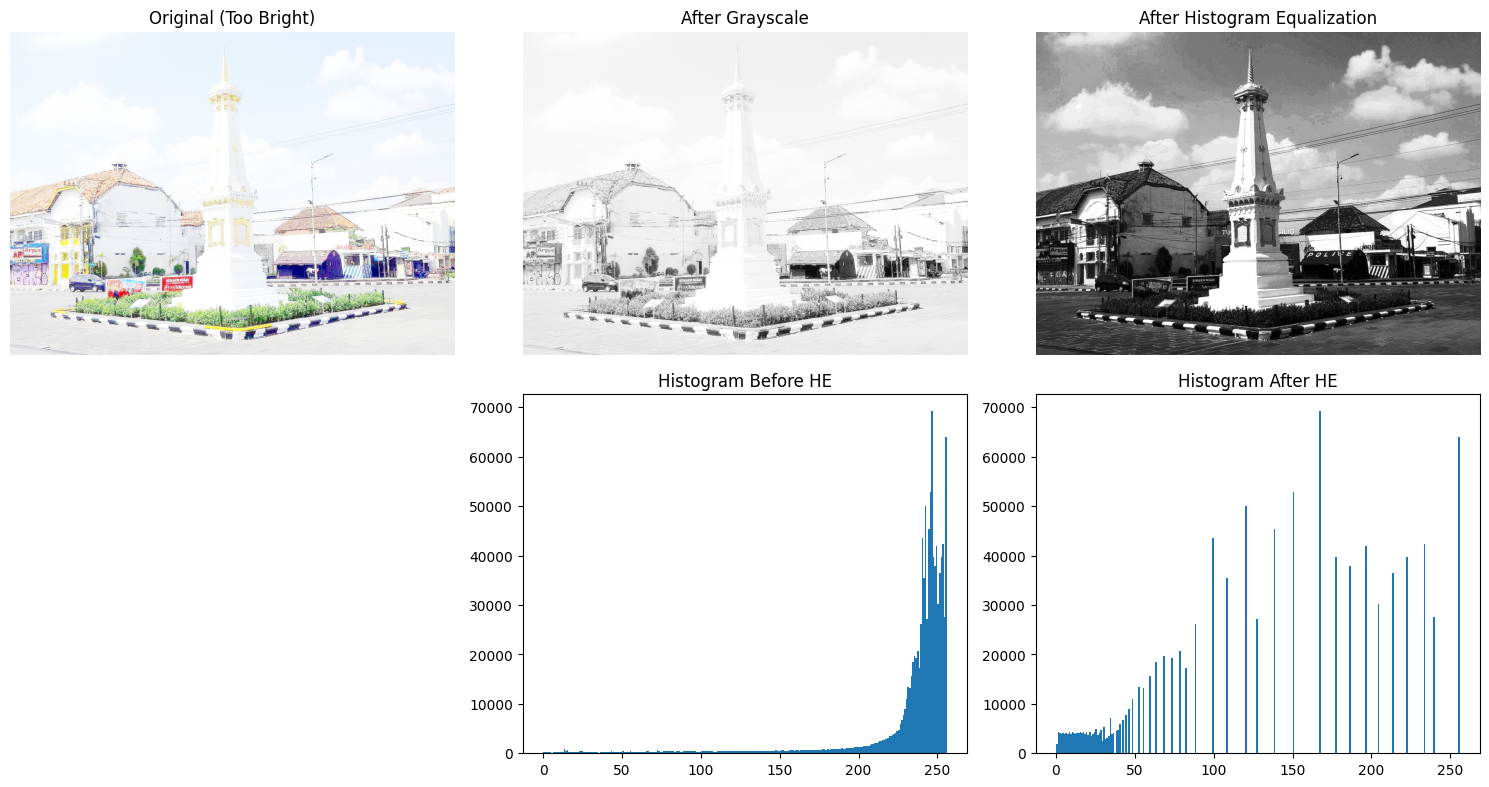

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

#link folder drive gambar: https://drive.google.com/drive/folders/1YSCrkI7UzqDmOdJf-DT7HkURekb3i2Fi?usp=sharing
img = cv2.imread('/content/drive/MyDrive/CVL_Assignment01/bright1.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# histogram equalization
equalized = cv2.equalizeHist(gray)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0,0].imshow(img)
axs[0,0].set_title('Original (Too Bright)')
axs[0,0].axis('off')

axs[0,1].imshow(gray, cmap='gray')
axs[0,1].set_title('After Grayscale')
axs[0,1].axis('off')

axs[0,2].imshow(equalized, cmap='gray')
axs[0,2].set_title('After Histogram Equalization')
axs[0,2].axis('off')

# histogram grayscale
axs[1,1].hist(gray.ravel(), bins=256, range=[0,256])
axs[1,1].set_title('Histogram Before HE')

# histogram equalized
axs[1,2].hist(equalized.ravel(), bins=256, range=[0,256])
axs[1,2].set_title('Histogram After HE')

axs[1,0].axis('off')

plt.tight_layout()
plt.show()